# Bài tập Buổi 7 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd '/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week03'

/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week03


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [4]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
missing_value_mean = df.isnull().mean()
print(missing_value_mean)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
drop_columns = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']
df = df.drop(columns=drop_columns)

# In các cột còn lại sau khi loại bỏ
print("Remaining columns: ", list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Remainning columns:  ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*

alive variable is the forecast target of the model. Unhide causes model knows result beforehand

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [5]:
# TODO 2: shape, info, describe

print("DataFrame Shape:", df.shape)
df.info()

print("\nObject Variables:", list(df.select_dtypes(include='object').columns))
print(df.describe(include='object'))

print("\nCategory Variables:", list(df.select_dtypes(include='category').columns))

print(df.describe(include='category'))

DataFrame Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Object Variables: ['sex', 'embarked', 'who', 'embar

**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*

Numeric Variable ['class', 'deck']

Category variable: ['who', 'embark_town', 'alive']


---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [6]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_value = pd.DataFrame({
    'Count': missing_count,
    'Percentage': missing_percentage
})
missing_value

,Count,Percentage
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467
class,0,0.000000
who,0,0.000000


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột         | % thiếu | Cách xử lý đề xuất | Lý do       |
|-------------|---------|--------------------|-------------|
| `deck`      | 77.21   | Drop column        | Risk missing (>70%) |
| `embark_town` | 0.22    | Substitube by Mode | Category Type. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [7]:

# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
# trả về số lượng outlier theo IQR
  s_drop = s.dropna()
  iqr = stats.iqr(s_drop)
  q1 = s_drop.quantile(0.25)
  q3 = s_drop.quantile(0.75)
  lower_bound = q1 - 1.5 * iqr
  upper_bound = q3 + 1.5 * iqr
  return (s_drop < lower_bound).sum() + (s_drop > upper_bound).sum()


def dem_outlier_zscore(s, nguong=3.0):
    # trả về số lượng outlier theo Z-score
  s_drop = s.dropna()
  z_scores = np.abs(stats.zscore(s_drop))
  return (z_scores > nguong).sum()
for col in ['age', 'fare']:
  print(f"Column: {col}")
  print(f"IQR Outliers: {dem_outlier_iqr(df[col])}")
  print(f"Z-score Outliers: {dem_outlier_zscore(df[col])}")
  #print(f"Outliers (Z-score): {dem_outlier_zscore(df[col])}"

Column: age
IQR Outliers: 11
Z-score Outliers: 2
Column: fare
IQR Outliers: 116
Z-score Outliers: 20


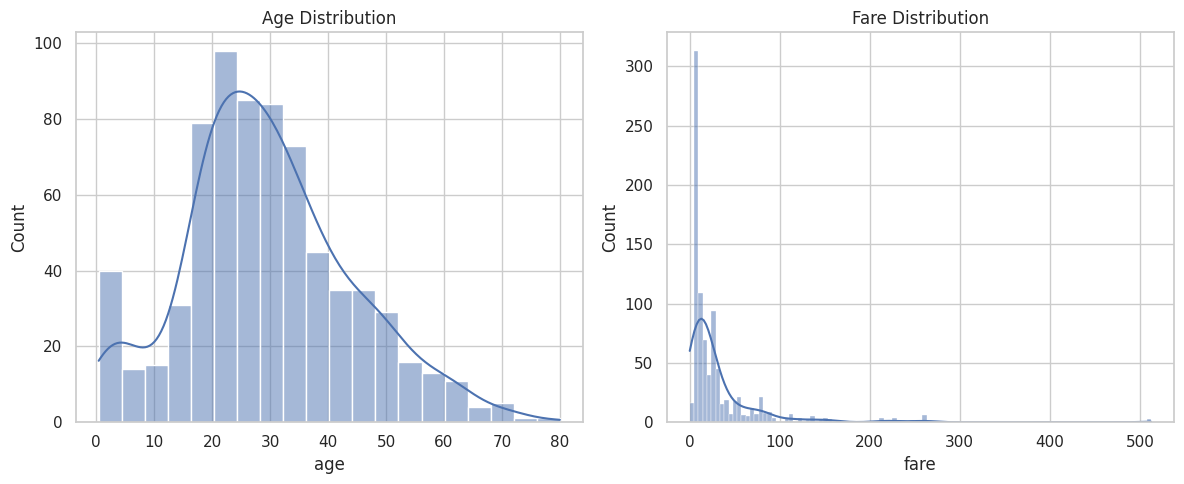

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*

`fare` variable remove outliers by IQR caculation. The reason is right skew.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

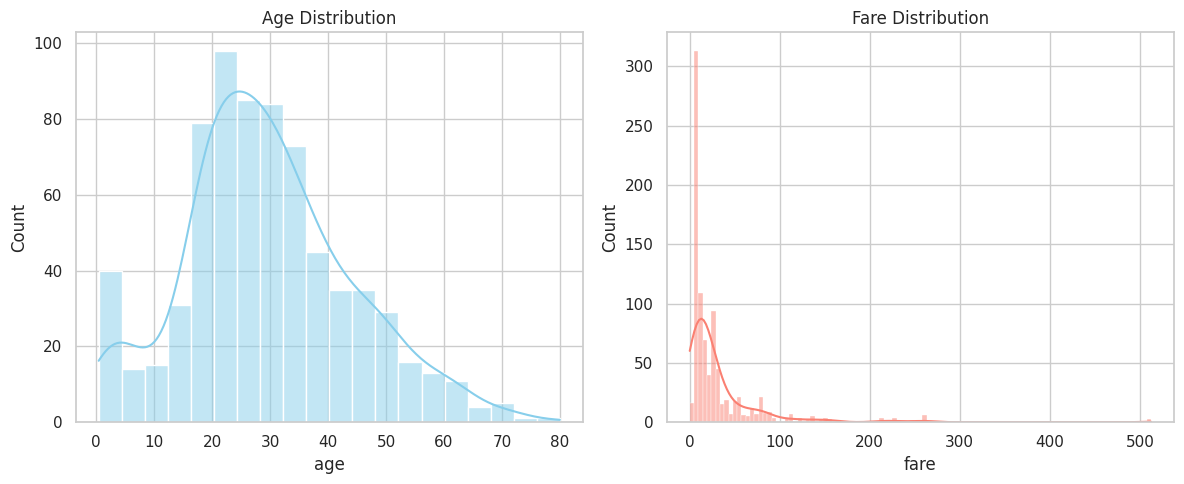

In [9]:
# TODO 5a: Histogram age & fare



fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['age'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['fare'].dropna(), kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

In [12]:
color_palette = sns.color_palette("Set2")

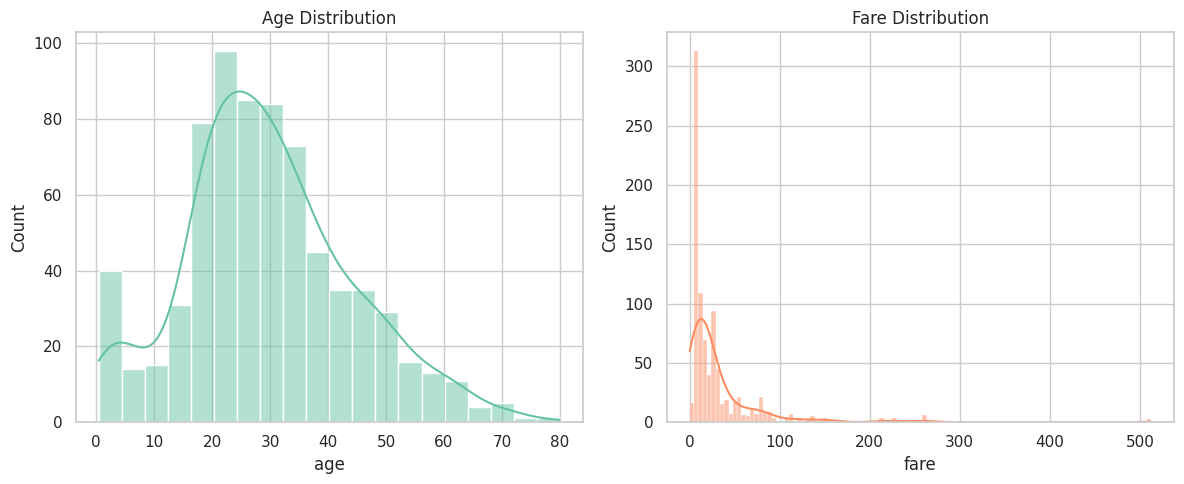

In [13]:
# TODO 5a: Histogram age & fare

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['age'].dropna(), kde=True, ax=axes[0], color=color_palette[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['fare'].dropna(), kde=True, ax=axes[1], color=color_palette[1])
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

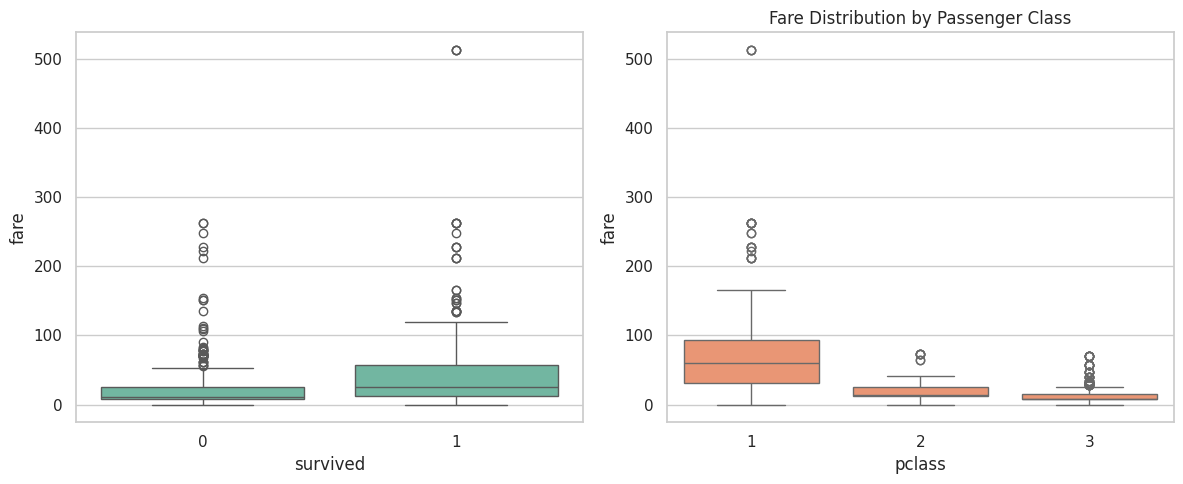

In [14]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='survived', y='fare', ax=axes[0], color=color_palette[0])
plt.title('Fare Distribution by Survival')

sns.boxplot(data=df, x='pclass', y='fare', ax=axes[1], color=color_palette[1])
plt.title('Fare Distribution by Passenger Class')

plt.tight_layout()
plt.show()

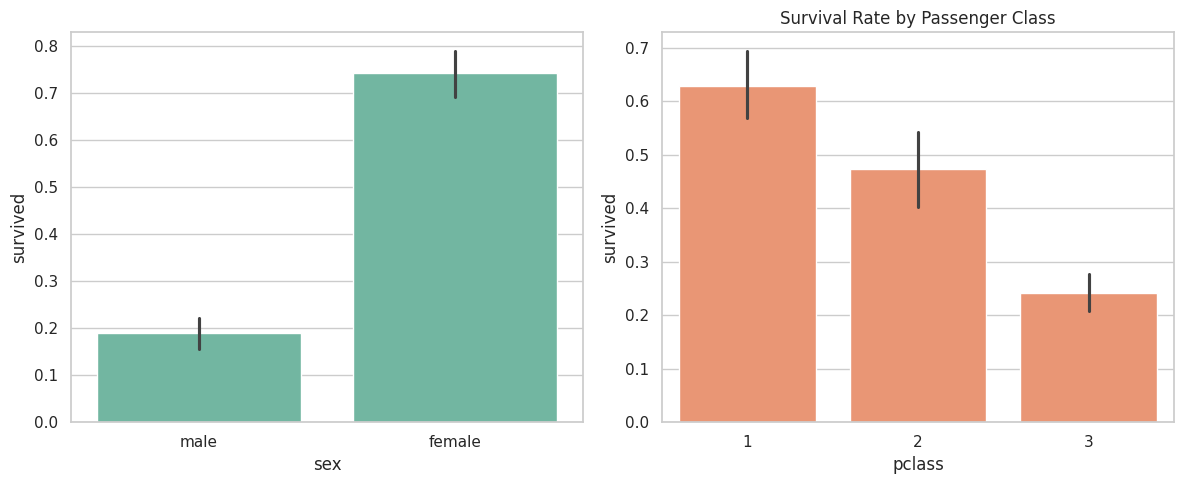

In [15]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='sex', y='survived', ax=axes[0], color=color_palette[0])
plt.title('Survival Rate by Sex')

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], color=color_palette[1])
plt.title('Survival Rate by Passenger Class')

plt.tight_layout()

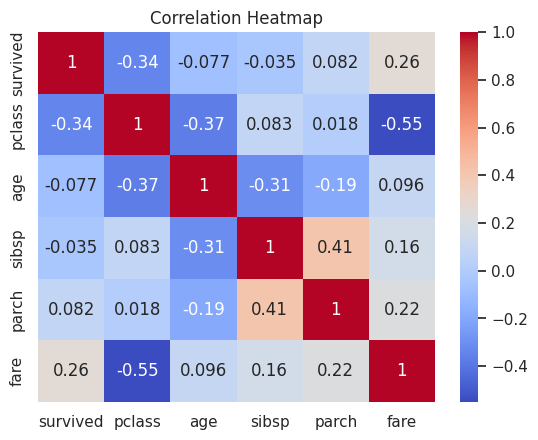

In [16]:
# TODO 5d: Heatmap correlation

sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram:
  Populate age is young adult, economy ticket is outnumber.

- Boxplot:
  The average of high price ticket have more survive chance.

  The class of ticket is the same as the price of ticket.
- Bar survival:
  Female has more survival chance than man.
  The same phenomena with `pclass`
- Heatmap:
  All variable is non-linear.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [35]:
# TODO 6: chia train/val/test có stratify
X = df.drop('survived', axis=1)
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.1765, stratify=y_tmp)
# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
# X_train, X_val, y_train, y_val = train_test_split(...)

# print("Train/Val/Test:", ...)
# in tỷ lệ survived từng tập
print(f"Train/Val/Test: {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")

Train/Val/Test: 623/134/134


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [36]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline(steps=[
    # ("imputer", ...),
    # ("scaler",  ...),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    # ("onehot",  ...),
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    # ("num", pipe_so,  num_cols),
    ('num', pipe_so, num_cols),

    # ("cat", pipe_cat, cat_cols),
    ('cat', pipe_cat, cat_cols),

    # ("ord", "passthrough", ord_cols),
    ('ord', 'passthrough', ord_cols)
])

# preprocess.fit(X_train)               # fit CHỈ trên train
preprocess.fit(X_train)

# X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(viết tại đây...)*

Tránh các thông số về phân phối, trung vị,  trung bình độ lệch chuẩn bị ghi nhớ trong mô hình tập test


---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [37]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời

survived_ratio = y_train.value_counts(normalize=True)
print(survived_ratio)

survived
0    0.616372
1    0.383628
Name: proportion, dtype: float64


**Trả lời 8:**

1. Mất cân bằng rõ rệt nhãn của `survived`
2. Có thể nhầm lẫn trong trường hợp trường hợp Recal = 0
3. Ưu tiên F1-Score hoặc Recall.Đảm bảo mô hình nhận diện 2 lớp dữ liệu mà không bị lệch. Tối ưu Recall giúp giảm thiểu tỷ lệ bỏ sót người sống sót

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1.  **Đặc trưng tương quan mạnh nhất với khả năng sống sót:** Dựa trên heatmap tương quan, các `pclass` có tương quan tiêu cực mạnh nhất, cho thấy hành khách ở khoang hạng thấp hơn có tỷ lệ sống sót thấp hơn. `fare` có tương quan dương, tức là những người trả vé đắt hơn có cơ hội sống sót cao hơn.
2.  **Cột thiếu nhiều nhất và cách xử lý:** Cột `deck` thiếu nhiều nhất với 77.22% giá trị bị thiếu. Với tỷ lệ missing quá cao này, cột `deck` đã được quyết định loại bỏ khỏi tập dữ liệu vì không đủ thông tin để điền vào một cách hợp lý và có thể gây nhiễu cho mô hình.
3.  **Biến mục tiêu có mất cân bằng không và ảnh hưởng đến metric:** Biến mục tiêu `survived` có mất cân bằng rõ rệt. Tỷ lệ hành khách không sống sót (`survived=0`) là 61.64% và sống sót (`survived=1`) là 38.36%. Sự mất cân bằng này ảnh hưởng đến việc lựa chọn metric đánh giá: chỉ nhìn vào `Accuracy` có thể gây hiểu lầm. Ví dụ, một mô hình luôn dự đoán `0` (không sống sót) sẽ đạt độ chính xác 61.64%, nhưng hoàn toàn bỏ sót những người sống sót (Recall = 0 cho lớp `1`). Do đó, nên ưu tiên các metric như `F1-Score` hoặc `Recall` để đảm bảo mô hình có thể nhận diện tốt cả hai lớp, đặc biệt là lớp thiểu số.
4.  **Đặc trưng nào cần scaling, đặc trưng nào cần encoding và vì sao:**
    *   **Scaling:** Các biến số như `age`, `sibsp`, `parch`, `fare` (`num_cols`) cần được scaling bằng `RobustScaler`. Lý do là các biến này có thang đo khác nhau và `fare` có outlier (như đã thấy trong boxplot và phân tích outlier ở Task 4). `RobustScaler` phù hợp vì ít nhạy cảm với outlier hơn `StandardScaler` hoặc `MinMaxScaler`.
    *   **Encoding:** Các biến phân loại như `sex` và `embarked` (`cat_cols`) cần được encoding bằng `OneHotEncoder`. Lý do là các mô hình học máy yêu cầu đầu vào là dạng số, và `OneHotEncoder` chuyển đổi các giá trị danh nghĩa thành biểu diễn số mà không tạo ra mối quan hệ thứ tự giả định giữa chúng.
    *   Biến `pclass` (`ord_cols`) được giữ nguyên (`passthrough`) vì nó đã là biến số có thứ tự (1, 2, 3) và thứ tự này có ý nghĩa.
5.  **Một điều bất ngờ/thú vị trong dữ liệu:** Một điều thú vị là sự chênh lệch đáng kể về tỷ lệ sống sót giữa nam và nữ, cũng như giữa các hạng vé (`pclass`). Phụ nữ có tỷ lệ sống sót cao hơn đáng kể so với nam giới, và hành khách ở khoang hạng nhất (`pclass=1`) có tỷ lệ sống sót cao hơn nhiều so với hạng hai và hạng ba. Điều này cho thấy các yếu tố xã hội và ưu tiên cứu hộ đóng vai trò quan trọng hơn các yếu tố ngẫu nhiên trong thảm họa Titanic.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

Li

In [59]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier


lin_model = LinearRegression()

lin_model.fit(X_train_t, y_train)
lin_y_pred = lin_model.predict(X_val_t)
# Convert continuous predictions to binary (0 or 1) for accuracy calculation
lin_y_pred = (lin_y_pred > 0.5).astype(int)

log_model = LogisticRegression(
    random_state = 42,
    max_iter = 1000,
    solver = 'liblinear'
)

log_model.fit(X_train_t, y_train)
log_y_pred = log_model.predict(X_val_t)

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_t, y_train)
knn_y_pred = knn_model.predict(X_val_t)

print(f"Linear Regression Accuracy: {accuracy_score(y_val, lin_y_pred)}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_val, log_y_pred)}")
print(f"KNN Accuracy: {accuracy_score(y_val, knn_y_pred)}")

Linear Regression Accuracy: 0.8134328358208955
Logistic Regression Accuracy: 0.835820895522388
KNN Accuracy: 0.8059701492537313


In [60]:
print(f'Linear Regression Classification Report:\n{classification_report(y_val, lin_y_pred)}')
print(f'Logistic Regression Classification Report:\n{classification_report(y_val, log_y_pred)}')
print(f'KNN Classification Report:\n{classification_report(y_val, knn_y_pred)}')

Linear Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85        82
           1       0.75      0.77      0.76        52

    accuracy                           0.81       134
   macro avg       0.80      0.81      0.80       134
weighted avg       0.81      0.81      0.81       134

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.78      0.81      0.79        52

    accuracy                           0.84       134
   macro avg       0.83      0.83      0.83       134
weighted avg       0.84      0.84      0.84       134

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        82
           1       0.80      0.67      0.73        52

    accuracy                           0.81       134
   macro avg     

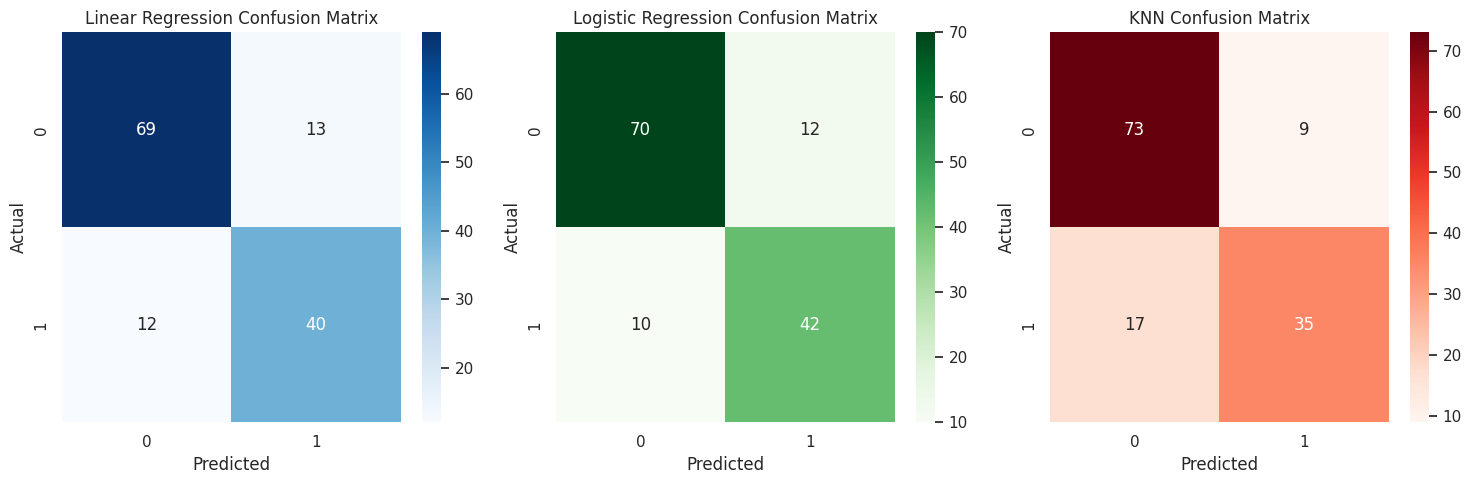

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_val, lin_y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Linear Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_val, log_y_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_val, knn_y_pred), annot=True, fmt='d', cmap='Reds', ax=axes[2])
axes[2].set_title('KNN Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

There is not significantly different between Linear and Logistic Regression by parameters.

KKN is the worst model of the group.